In [48]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

In [49]:
data = pd.read_csv("../data/grid-results.csv")
circuit_types = pd.read_csv("../data/circuit-type.csv")
data["GridPosition"] = data["GridPosition"].astype("int")
data["ClassifiedPosition"] = data["ClassifiedPosition"].astype("int")
data["circuitType"] = data["circuitId"].map(circuit_types.set_index("circuitId")["trackType"])
data["IsStreetCircuit"] = (data["circuitType"] == "street").astype("int")
data["IsGroundEffect"] = (data["year"] >= 2022).astype("int")
data[["GridPosition", "ClassifiedPosition", "IsStreetCircuit", "IsGroundEffect"]]

,GridPosition,ClassifiedPosition,IsStreetCircuit,IsGroundEffect
0,3,1,1,0
1,1,2,1,0
2,2,3,1,0
3,8,4,1,0
4,10,5,1,0
...,...,...,...,...
1650,4,6,0,1
1651,5,7,0,1
1652,7,8,0,1
1653,8,9,0,1


In [50]:
grid_mean = data["GridPosition"].mean()
grid_std = data["GridPosition"].std()
grid_z = (data["GridPosition"] - grid_mean) / grid_std
grid_z

finishing_position = data["ClassifiedPosition"]
finish_idx = finishing_position - 1
finish_idx

0       0
1       1
2       2
3       3
4       4
       ..
1650    5
1651    6
1652    7
1653    8
1654    9
Name: ClassifiedPosition, Length: 1655, dtype: int64

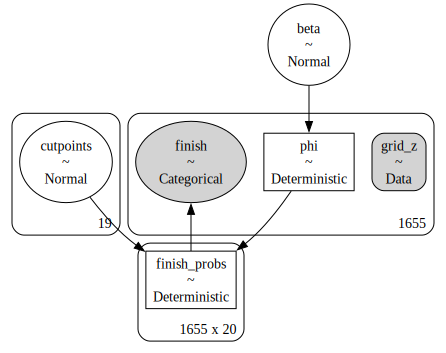

In [62]:
K = int(finish_idx.max()) + 1

with pm.Model() as model:
    # data
    pm.Data("grid_z", grid_z)

    # priors
    beta = pm.Normal("beta", mu=0, sigma=1)
    cutpoints = pm.Normal(
        "cutpoints",
        mu=np.linspace(-2, 2, K - 1),
        sigma=1.5,
        transform=pm.distributions.transforms.ordered,
        initval=np.linspace(-2, 2, K - 1),
        shape=K - 1,
    )

    # Linear Predictor
    phi = pm.Deterministic("phi", beta * grid_z)

    # Likelihood
    finish = pm.OrderedLogistic("finish", eta=phi, cutpoints=cutpoints, observed=finish_idx)

pm.model_to_graphviz(model)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, cutpoints]


                                                               
                          Step    Grad    Sam…                 
  Prog…   Draws   Dive…   size    evals   Spe…   Elap…   Rem…  
 ───────────────────────────────────────────────────────────── 
                                                               
                          Step    Grad    Sam…                 
  Prog…   Draws   Dive…   size    evals   Spe…   Elap…   Rem…  
 ───────────────────────────────────────────────────────────── 
  ━━━━━   0       0       0.000   0       0.00   0:00…   -:-…  
                                          dra…                 
                                                               
                          Step    Grad    Sam…                 
  Prog…   Draws   Dive…   size    evals   Spe…   Elap…   Rem…  
 ───────────────────────────────────────────────────────────── 
  ━━━━━   0       0       0.000   0       0.00   0:00…   -:-…  
                                        

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 32 seconds.
Sampling: [finish]


Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:26 0:00:01 / 0:00:2600:02 / 0:00:25


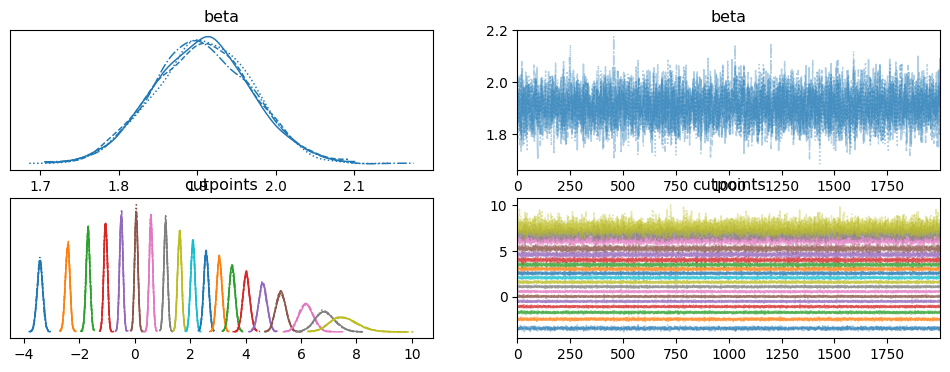

In [63]:
N_DRAWS = 2000
N_TUNES = 1000
N_CHAINS = 4
N_TARGET_ACCEPT = 0.95
SEED = 39

with model:
    trace = pm.sample(
        draws=N_DRAWS,
        tune=N_TUNES,
        chains=N_CHAINS,
        target_accept=N_TARGET_ACCEPT,
        random_seed=SEED,
    )
    pm.sample_posterior_predictive(trace, extend_inferencedata=True, var_names=["finish"], random_seed=SEED)
az.plot_trace(trace, var_names=["beta", "cutpoints"])
plt.show()

In [58]:
grid_positions = np.arange(1, 21)

posterior = trace.posterior
beta_samples = posterior["beta"].values.flatten()          # (draws,)
cutpoints_samples = posterior["cutpoints"].values.reshape(-1, posterior["cutpoints"].shape[-1])  # (draws, K-1)

K = cutpoints_samples.shape[1] + 1
records = []

for gp in grid_positions:
    gp_z = (gp - grid_mean) / grid_std
    eta = beta_samples * gp_z    # (draws,)

    # Cumulative probabilities via logistic CDF
    # P(finish <= k) = logistic(cutpoints[k] - eta)
    cum_probs = 1.0 / (1.0 + np.exp(-(cutpoints_samples - eta[:, None])))  # (draws, K-1)

    # Cell probabilities: P(finish = k) = P(finish<=k) - P(finish<=k-1)
    # Prepend 0 and append 1 for boundary conditions
    zeros = np.zeros((cum_probs.shape[0], 1))
    ones  = np.ones((cum_probs.shape[0], 1))
    cum_full = np.hstack([zeros, cum_probs, ones])           # (draws, K+1)
    cell_probs = np.diff(cum_full, axis=1)                    # (draws, K)

    mean_probs = cell_probs.mean(axis=0)                      # (K,)

    for k, prob in enumerate(mean_probs):
        records.append({
            "grid_position": int(gp),
            "finish_position": k + 1,     # back to 1-indexed
            "probability": float(prob),
        })
results_df = pd.DataFrame.from_records(records)
results_df

,grid_position,finish_position,probability
0,1,1,0.293718
1,1,2,0.235937
2,1,3,0.172282
3,1,4,0.114152
4,1,5,0.070490
...,...,...,...
395,20,16,0.134248
396,20,17,0.123579
397,20,18,0.049890
398,20,19,0.027503


In [ ]:
summary = az.summary(trace , var_names=["beta", "cutpoints"], round_to=3)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,1.906,0.061,1.795,2.022,0.001,0.001,6721.391,6265.757,1.000
cutpoints[0],-3.431,0.101,-3.621,-3.241,0.001,0.001,5790.679,6119.529,1.000
cutpoints[1],-2.431,0.081,-2.583,-2.282,0.001,0.001,7816.366,6479.128,1.000
cutpoints[2],-1.691,0.070,-1.820,-1.560,0.001,0.001,8579.419,6840.913,1.000
cutpoints[3],-1.057,0.064,-1.182,-0.943,0.001,0.001,9247.968,7517.893,1.000
cutpoints[4],-0.490,0.061,-0.604,-0.376,0.001,0.001,9213.331,6542.831,1.000
cutpoints[5],0.049,0.060,-0.069,0.160,0.001,0.001,9737.155,6988.242,1.000
cutpoints[6],0.581,0.064,0.459,0.699,0.001,0.001,9350.921,6868.991,1.000
cutpoints[7],1.111,0.068,0.979,1.233,0.001,0.001,10074.414,7075.375,1.000
cutpoints[8],1.615,0.074,1.483,1.759,0.001,0.001,8895.621,6766.342,1.000


In [64]:
trace.to_netcdf("basic-model-v1.nc")

'basic-model-v1.nc'